# Analisis Data Polutan Udara di Wilayah Kecamatan Tikala Kabupaten Manado

Dokumen ini menyajikan analisis terhadap enam jenis polutan udara (CO, NO2, HCHO, O3, SO2, dan CH4) di wilayah Minahasa/Manado dengan memanfaatkan data satelit Sentinel-5P. Pembahasan pada tugas ini dibatasi hingga tahap Business Understanding dan Data Understanding.

## 1. Business Understanding

### 1.1 Latar Belakang

Pemantauan kualitas udara merupakan hal penting untuk dilakukan, mengingat polutan di atmosfer dapat berasal dari aktivitas manusia (transportasi, industri, pembakaran, maupun pertanian) atau dari proses alami seperti aktivitas vulkanik. Kombinasi sumber tersebut dapat berbeda-beda antarwilayah, bergantung pada karakteristik masing-masing daerah.

Analisis pada tugas ini difokuskan pada enam jenis polutan udara di wilayah Kecamatan Tikala dengan memanfaatkan data Sentinel-5P selama periode pengamatan kurang lebih satu tahun.

### 1.2 Tujuan Analisis

1. Mengumpulkan data enam polutan udara sepanjang periode pengamatan yang ditentukan.
2. Mengamati perkembangan konsentrasi masing-masing polutan dari waktu ke waktu.
3. Mengidentifikasi kemungkinan sumber emisi dari tiap polutan.
4. Melakukan tahap Data Understanding, mencakup pemeriksaan struktur data, missing value, outlier, dan visualisasi time series.

### 1.3 Manfaat Analisis

Hasil analisis ini diharapkan dapat memberikan gambaran awal mengenai kondisi kualitas udara di Keecamatan Tikala, sekaligus membantu mengenali pola konsentrasi polutan sepanjang waktu. Temuan pada tahap ini juga dapat menjadi landasan bagi tahap analisis lanjutan, misalnya pemodelan atau prediksi kualitas udara.

### 1.4 Penjelasan dan Kemungkinan Sumber Tiap Polutan

| Polutan | Apa Itu? | Kemungkinan Sumber |
|---|---|---|
| **CO** (Karbon Monoksida) | Gas tak berwarna dan tak berbau, muncul dari pembakaran bahan bakar yang tidak sempurna. Berbahaya karena mengikat hemoglobin lebih kuat dari oksigen. | Kendaraan bermotor, kebakaran lahan/hutan, pembakaran biomassa |
| **NO2** (Nitrogen Dioksida) | Gas coklat kemerahan berbau tajam, terbentuk dari oksidasi NO di udara. Ikut memicu hujan asam dan pembentukan ozon permukaan. | Kendaraan bermotor, industri, pembangkit listrik |
| **HCHO** (Formaldehida) | Senyawa organik volatil (VOC), sering dipakai sebagai penanda tak langsung emisi VOC di atmosfer. | Emisi vegetasi, pembakaran biomassa, kendaraan, industri |
| **O3** (Ozon Permukaan) | Bukan gas yang langsung diemisikan, melainkan polutan sekunder hasil reaksi fotokimia NOx dan VOC dengan bantuan sinar matahari. | Reaksi emisi kendaraan/industri (NOx, VOC) dengan sinar matahari |
| **SO2** (Sulfur Dioksida) | Gas tak berwarna berbau tajam, dihasilkan dari pembakaran bahan bakar yang mengandung sulfur. | Pembakaran bahan bakar fosil, industri, aktivitas vulkanik |
| **CH4** (Metana) | Gas rumah kaca dengan efek pemanasan jauh lebih kuat dari CO2, tak berwarna dan tak berbau. | Pertanian (sawah), peternakan, TPA, kebocoran gas alam |


### 1.5 Deskripsi Data

- Sumber data: Sentinel-5P (`SENTINEL_5P_L2`), diakses melalui layanan openEO pada Copernicus Data Space Ecosystem.
- Cakupan wilayah: Minahasa/Manado, dibatasi menggunakan polygon GeoJSON yang dibuat lewat geojson.io.
- Periode pengamatan yang ditargetkan: 31 Agustus 2025 s.d. 31 Agustus 2026 (realisasi akhirnya sedikit berbeda, lihat Bagian 2.2).
- Polutan yang diamati: CO, NO2, HCHO, O3, SO2, dan CH4, masing-masing dalam bentuk rata-rata harian untuk seluruh wilayah kajian.
- Keluaran: berkas `.csv` dengan kolom `date, CO, NO2, HCHO, O3, SO2, CH4`.

## 2. Data Understanding

### 2.1 Pengumpulan Data

Data diperoleh dari koleksi `SENTINEL_5P_L2` melalui openEO. Pengambilan dilakukan per polutan secara terpisah, kemudian hasilnya digabungkan menjadi satu tabel berdasarkan kolom tanggal.

In [1]:
# library openeo untuk ambil data satelit, netCDF4 untuk baca hasil unduhannya
!pip install openeo netCDF4 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 357.0/357.0 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 55.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 4.4 MB/s eta 0:00:00


Menjalankan sel di bawah ini akan menampilkan tautan autentikasi. Buka tautan tersebut, login menggunakan akun Copernicus, lalu kembali ke notebook untuk melanjutkan.

In [2]:
import openeo
import netCDF4
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt

connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Visit https://identity.dataspace.copernicus.eu/auth/realms/CDSE/device?user_code=HFPA-PLSE 📋 to authenticate.

✅ Authorized successfully

Authenticated using device code flow.


**penjelasan code:**

* Pustaka `openeo` digunakan untuk menghubungkan notebook ke server Copernicus tempat data Sentinel-5P disimpan.
* Baris terakhir sekaligus membuka koneksi dan melakukan proses autentikasi (login).

#### 2.1.1 Wilayah Penelitian (Area of Interest)

Batas wilayah kajian disusun dari polygon GeoJSON yang dibuat melalui geojson.io. Polygon tersebut digunakan untuk menghitung rata-rata polutan di dalam area kajian, sedangkan bounding box berfungsi sebagai batas awal saat data ditarik dari server.

> ![](https://cdn.mathpix.com/snip/images/AOB8iFGYBoXXm2GNXN4GH0yszigrNepTDXZpOTJmqbc.original.fullsize.png)

In [3]:
import json

with open("Tikala.geojson") as f:
    _geo = json.load(f)

AOI = _geo["features"][0]["geometry"]["geometries"][0]

titik = AOI["coordinates"][0]
lons = [p[0] for p in titik]
lats = [p[1] for p in titik]
BBOX = {"west": min(lons), "south": min(lats),
        "east": max(lons), "north": max(lats)}

**penjelasan code:**

* `AOI` merupakan polygon yang menandai batas wilayah Minahasa/Manado.
* `BBOX` adalah kotak pembatas terluar dari polygon tersebut, digunakan server untuk membatasi area yang diunduh.

#### 2.1.2 Periode dan Daftar Polutan

Data ditargetkan untuk periode satu tahun hingga 31 Agustus 2026, yaitu 31 Agustus 2025 – 31 Agustus 2026. Nilai `END_DATE` ditulis `2026-09-01` karena batas akhir bersifat exclusive, sehingga tanggal 31 Agustus tetap ikut terambil.

In [4]:
START_DATE = "2025-08-31"
END_DATE = "2026-09-01"   # supaya 31 Agustus 2026 tetap terambil

POLLUTANTS = ["CO", "NO2", "HCHO", "O3", "SO2", "CH4"]

#### 2.1.3 Fungsi Pengambilan dan Pembacaan Data

Fungsi `ambil_data()` menarik data satu polutan dari Sentinel-5P, menghitung rata-rata harian kemudian rata-rata spasial untuk seluruh AOI, dan menyimpan hasilnya sebagai berkas NetCDF.

Fungsi `baca_nc()` membaca berkas NetCDF tersebut menjadi tabel berisi kolom tanggal dan nilai polutan. Karena struktur dimensi tiap berkas NetCDF dapat berbeda antarpolutan, fungsi ini secara otomatis mencari dimensi yang panjangnya sesuai dengan jumlah tanggal untuk ditetapkan sebagai dimensi waktu. Dimensi lain di luar dimensi waktu kemudian dirata-ratakan agar setiap tanggal hanya memiliki satu nilai.

In [5]:
def ambil_data(polutan):
    data = connection.load_collection(
        "SENTINEL_5P_L2",
        temporal_extent=[START_DATE, END_DATE],
        spatial_extent=BBOX,
        bands=[polutan]
    )

    data_harian = data.aggregate_temporal_period(
        reducer="mean",
        period="day"
    )

    data_wilayah = data_harian.aggregate_spatial(
        reducer="mean",
        geometries=AOI
    )

    file_output = f"{polutan}_Manado.nc"

    data_wilayah.execute_batch(
        title=f"Data {polutan}",
        outputfile=file_output
    )

    return file_output


def baca_nc(file, polutan):
    data = netCDF4.Dataset(file)

    nilai = np.ma.filled(
        data.variables[polutan][:],
        np.nan
    )

    waktu = data.variables["t"]
    tanggal = netCDF4.num2date(
        waktu[:],
        units=waktu.units
    )

    jumlah_tanggal = len(tanggal)

    # cari dimensi yang panjangnya sama dengan jumlah tanggal -> itu dimensi waktu
    time_axis = next(
        (axis for axis, ukuran in enumerate(nilai.shape)
         if ukuran == jumlah_tanggal),
        None
    )

    if time_axis is None:
        raise ValueError(
            f"Dimensi waktu tidak ditemukan. Shape: {nilai.shape}"
        )

    nilai = np.moveaxis(nilai, time_axis, 0)

    if nilai.ndim > 1:
        nilai = np.nanmean(
            nilai,
            axis=tuple(range(1, nilai.ndim))
        )

    return pd.DataFrame({
        "date": [x.strftime("%Y-%m-%d") for x in tanggal],
        polutan: nilai
    })

**penjelasan code:**

* `ambil_data()` melakukan query data mentah dari `SENTINEL_5P_L2`, mengagregasinya menjadi rata-rata harian per wilayah, lalu menyimpannya sebagai berkas `.nc`.
* `baca_nc()` membuka berkas `.nc`, mengonversi nilai kosong menjadi NaN, menyesuaikan dimensi waktu dengan jumlah tanggal, kemudian mengembalikan hasilnya sebagai tabel berisi tanggal dan nilai polutan.

#### 2.1.4 Menjalankan Pengambilan untuk Seluruh Polutan

Setiap polutan diproses satu per satu, kemudian digabungkan berdasarkan kolom `date` dan disimpan dalam format CSV.

In [6]:
df = None

for polutan in POLLUTANTS:
    print(f"Mengambil: {polutan}")

    file = ambil_data(polutan)
    data = baca_nc(file, polutan)

    if df is None:
        df = data
    else:
        df = df.merge(data, on="date", how="outer")

df = df.sort_values("date").reset_index(drop=True)
df.to_csv("pollutant_data_manado.csv", index=False)

print("\nData berhasil disimpan!")
print("Tanggal pertama:", df["date"].min())
print("Tanggal terakhir:", df["date"].max())
print("Jumlah baris:", len(df))

Mengambil: CO
0:00:00 Job 'j-2609120654434bc196f1f886b3ff6f0e': send 'start'
0:00:04 Job 'j-2609120654434bc196f1f886b3ff6f0e': queued (progress 0%)
0:00:10 Job 'j-2609120654434bc196f1f886b3ff6f0e': queued (progress 0%)
0:00:16 Job 'j-2609120654434bc196f1f886b3ff6f0e': queued (progress 0%)
0:00:24 Job 'j-2609120654434bc196f1f886b3ff6f0e': queued (progress 0%)
0:00:34 Job 'j-2609120654434bc196f1f886b3ff6f0e': running (progress N/A)
0:00:47 Job 'j-2609120654434bc196f1f886b3ff6f0e': running (progress N/A)
0:01:03 Job 'j-2609120654434bc196f1f886b3ff6f0e': running (progress N/A)
0:01:22 Job 'j-2609120654434bc196f1f886b3ff6f0e': running (progress N/A)
0:01:46 Job 'j-2609120654434bc196f1f886b3ff6f0e': running (progress N/A)
0:02:16 Job 'j-2609120654434bc196f1f886b3ff6f0e': running (progress N/A)
0:02:54 Job 'j-2609120654434bc196f1f886b3ff6f0e': running (progress N/A)
0:03:41 Job 'j-2609120654434bc196f1f886b3ff6f0e': finished (progress 100%)
Mengambil: NO2
0:00:00 Job 'j-2609120658304f9e8b0f48e

**penjelasan code:**

* Iterasi dilakukan untuk setiap polutan, kemudian digabungkan menggunakan `merge(..., how="outer")` agar tanggal yang tidak memiliki nilai pada satu polutan tetap tersimpan sebagai NaN, bukan hilang dari tabel.
* Hasil akhirnya diurutkan berdasarkan tanggal, lalu disimpan ke berkas `pollutant_data_manado.csv`.

### 2.2 Struktur dan Isi Data

Mulai bagian ini, data dibaca kembali dari berkas CSV yang telah tersimpan sehingga notebook dapat dijalankan ulang dari titik ini tanpa perlu mengunduh data dari awal. Selanjutnya dilakukan pemeriksaan struktur data, meliputi jumlah baris, nama kolom, tipe data, dan rentang tanggal.

In [7]:
df = pd.read_csv("pollutant_data_manado.csv", parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)

POLLUTANTS = ["CO", "NO2", "HCHO", "O3", "SO2", "CH4"]
df.head()

,date,CO,NO2,HCHO,O3,SO2,CH4
0,2025-08-31,0.027904,NaN,NaN,0.114727,NaN,NaN
1,2025-09-01,NaN,NaN,NaN,0.115519,NaN,NaN
2,2025-09-02,0.025303,NaN,NaN,0.113351,NaN,NaN
3,2025-09-03,0.021577,NaN,-0.00003,0.113550,-0.000074,NaN
4,2025-09-04,0.022777,NaN,NaN,0.112023,NaN,NaN


In [8]:
print(f"Jumlah baris: {len(df)}")
print(f"Kolom: {list(df.columns)}")
print(f"Rentang tanggal: {df['date'].min().date()} s.d. {df['date'].max().date()}")
print()
print("Tipe data per kolom:")
print(df.dtypes)

Jumlah baris: 363
Kolom: ['date', 'CO', 'NO2', 'HCHO', 'O3', 'SO2', 'CH4']
Rentang tanggal: 2025-08-31 s.d. 2026-08-31

Tipe data per kolom:
date    datetime64[ns]
CO             float64
NO2            float64
HCHO           float64
O3             float64
SO2            float64
CH4            float64
dtype: object


In [9]:
# cek tanggal mana saja yang tidak ada di data (hilang total di semua polutan)
semua_tanggal = pd.date_range(start=df["date"].min(), end=df["date"].max())
tanggal_hilang = semua_tanggal.difference(df["date"])
print(f"Jumlah tanggal hilang: {len(tanggal_hilang)}")
print(tanggal_hilang)

Jumlah tanggal hilang: 3
DatetimeIndex(['2025-09-20', '2026-02-23', '2026-04-15'], dtype='datetime64[ns]', freq=None)


**penjelasan code:**

* `pd.date_range()` menghasilkan daftar seluruh tanggal dari awal hingga akhir periode data secara berurutan tanpa ada yang terlewat.
* `.difference(df["date"])` membandingkan daftar tersebut dengan tanggal yang benar-benar tercatat di `df`, sehingga diperoleh tanggal yang hilang sepenuhnya (tidak memiliki nilai pada satu pun polutan).

Data yang berhasil terekam mencakup rentang penuh 31 Agustus 2025 – 31 Agustus 2026, sesuai target satu tahun yang ditetapkan sebelumnya. Meski demikian, terdapat tiga tanggal (20 September 2025, 23 Februari 2026, dan 15 April 2026) yang sama sekali tidak memiliki observasi pada keenam polutan, kemungkinan karena wilayah kajian tertutup awan secara penuh pada tanggal-tanggal tersebut. Setelah memperhitungkan hal ini, dataset akhir yang tersimpan berjumlah 363 baris, dari total 366 hari kalender pada rentang tersebut.

### 2.3 Statistik Deskriptif

In [10]:
print("Statistik deskriptif:")
df[POLLUTANTS].describe()

Statistik deskriptif:


,CO,NO2,HCHO,O3,SO2,CH4
count,183.000000,123.000000,197.000000,359.000000,182.000000,5.000000
mean,0.025533,0.000008,0.000114,0.114543,0.000012,1894.347119
std,0.003863,0.000007,0.000125,0.005495,0.000183,22.388629
min,0.016487,-0.000017,-0.000256,0.104789,-0.000620,1866.367920
25%,0.022822,0.000004,0.000043,0.109673,-0.000078,1879.579590
50%,0.025266,0.000008,0.000114,0.113959,0.000006,1894.540649
75%,0.027985,0.000012,0.000190,0.118988,0.000088,1908.600098
max,0.039285,0.000029,0.000505,0.126100,0.000959,1922.647339


Terlihat bahwa skala nilai antarpolutan berbeda cukup jauh. CH4 berada pada kisaran ribuan (rata-rata ≈ 1.894), sementara NO2 dan SO2 berada pada kisaran 0,00001 (rata-rata masing-masing 0,000008 dan 0,000012). Perbedaan ini wajar mengingat satuan konsentrasi tiap gas memang tidak sama, dan menjadi alasan mengapa grafik time series pada bagian berikutnya perlu dinormalisasi terlebih dahulu agar dapat dibandingkan pada satu sumbu yang sama.

### 2.4 Missing Value

Data satelit rentan memiliki missing value, umumnya disebabkan oleh tutupan awan yang tebal, kualitas observasi yang rendah, atau data yang telah difilter melalui proses QA (quality assurance) oleh Sentinel-5P.

In [11]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_summary = pd.DataFrame({"jumlah_null": missing, "persen_null": missing_pct})
missing_summary

,jumlah_null,persen_null
date,0,0.00
CO,180,49.59
NO2,240,66.12
HCHO,166,45.73
O3,4,1.10
SO2,181,49.86
CH4,358,98.62


Persentase missing value bervariasi antarpolutan: NO2 sekitar 66,12%, CO 49,59%, SO2 49,86%, dan HCHO 45,73%. Kondisi yang paling mencolok terdapat pada CH4, yang datanya kosong hingga sekitar 98,62%. Hal ini diduga karena band CH4 pada Sentinel-5P memang jarang memiliki cakupan atau kualitas observasi yang memadai untuk wilayah sekecil Tikala Manado, ditambah gangguan tutupan awan tropis yang cukup sering terjadi.

### 2.5 Deteksi Outlier / Data Aneh

Pemeriksaan outlier dilakukan menggunakan metode IQR: nilai yang berada di bawah `Q1 - 1.5×IQR` atau di atas `Q3 + 1.5×IQR` dikategorikan sebagai outlier. Nilai ekstrem tersebut tidak langsung dihilangkan karena berpotensi mencerminkan kondisi nyata, misalnya lonjakan polusi akibat kebakaran lahan.

In [12]:
outlier_summary = []

for pol in POLLUTANTS:
    q1, q3 = df[pol].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr

    n_outlier = ((df[pol] < lower) | (df[pol] > upper)).sum()
    n_valid = df[pol].notna().sum()

    outlier_summary.append({
        "polutan": pol,
        "jumlah_outlier": n_outlier,
        "persen_outlier": round(n_outlier / n_valid * 100, 2) if n_valid else 0
    })

outlier_df = pd.DataFrame(outlier_summary)
outlier_df

,polutan,jumlah_outlier,persen_outlier
0,CO,2,1.09
1,NO2,7,5.69
2,HCHO,7,3.55
3,O3,0,0.00
4,SO2,12,6.59
5,CH4,0,0.00


**penjelasan code:**

* Batas atas dan bawah outlier dihitung menggunakan metode IQR, kemudian dihitung jumlah data yang berada di luar rentang tersebut untuk masing-masing polutan.

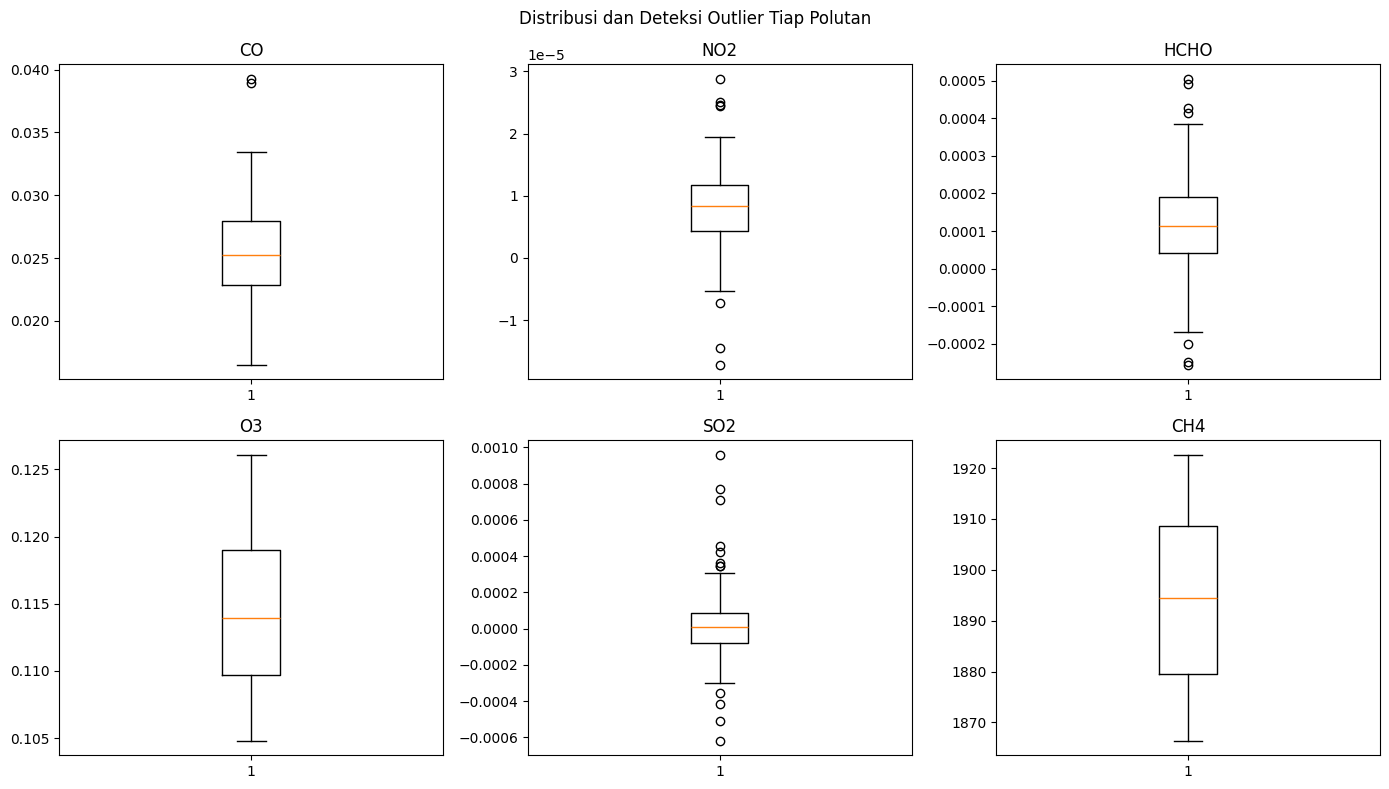

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, pol in zip(axes, POLLUTANTS):
    ax.boxplot(df[pol].dropna(), vert=True)
    ax.set_title(pol)

fig.suptitle("Distribusi dan Deteksi Outlier Tiap Polutan")
plt.tight_layout()
plt.show()

Berdasarkan tabel maupun boxplot, jumlah outlier bervariasi antarpolutan. O3 dan CH4 sama-sama tidak menunjukkan outlier sama sekali (0%), sementara SO2 (6,50%) dan NO2 (5,69%) memiliki proporsi outlier tertinggi, ditunjukkan oleh banyaknya titik di luar whisker pada kedua arah boxplot-nya. HCHO berada di posisi menengah (3,55%), sedangkan CO memiliki outlier paling sedikit di antara polutan yang masih menunjukkan outlier (1,09%).

Hal lain yang perlu dicatat, nilai minimum pada NO2, HCHO, dan SO2 di statistik deskriptif sebelumnya sedikit negatif. Secara fisik, konsentrasi gas tidak mungkin bernilai negatif. Kondisi ini muncul akibat noise pada proses retrieval satelit ketika konsentrasi sebenarnya sangat rendah atau mendekati nol, dan cukup umum dijumpai pada data Sentinel-5P. Nilai tersebut tetap dipertahankan pada tahap ini dan tidak diperlakukan sebagai kesalahan input.

### 2.6 Grafik Time Series

Pada bagian ini dibuat dua jenis grafik: grafik gabungan yang telah dinormalisasi ke rentang 0–1 untuk membandingkan pola seluruh polutan dalam satu sumbu, serta grafik terpisah per polutan dengan skala aslinya agar perubahan masing-masing polutan, termasuk CH4 yang datanya sangat terbatas, tetap dapat teramati dengan jelas.

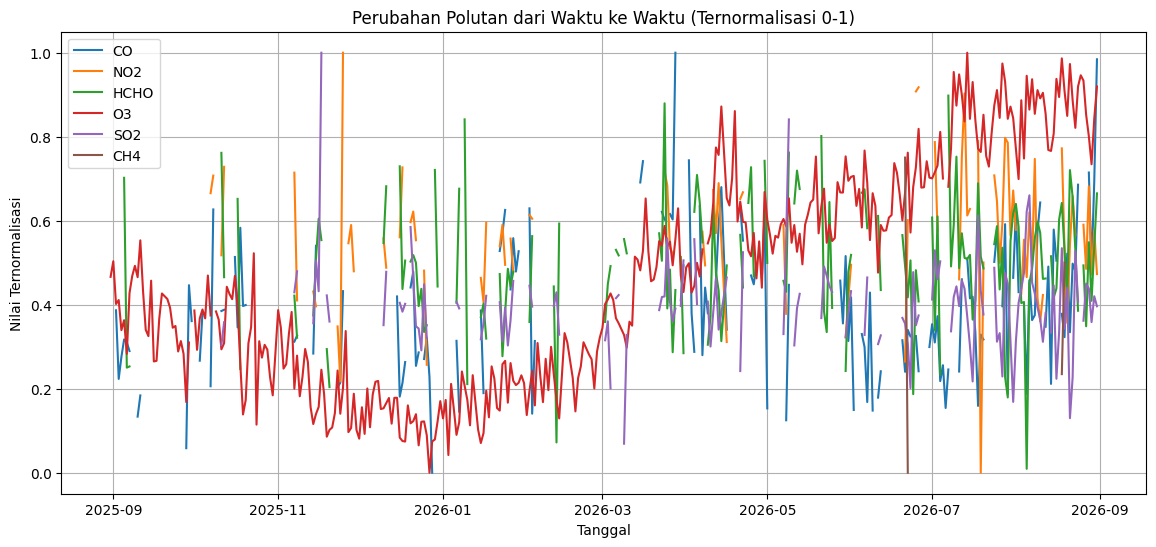

In [14]:
df_normalisasi = df[POLLUTANTS].copy()

for polutan in POLLUTANTS:
    nilai_min = df_normalisasi[polutan].min()
    nilai_max = df_normalisasi[polutan].max()
    df_normalisasi[polutan] = (df_normalisasi[polutan] - nilai_min) / (nilai_max - nilai_min)

plt.figure(figsize=(14, 6))

for polutan in POLLUTANTS:
    plt.plot(df["date"], df_normalisasi[polutan], label=polutan)

plt.title("Perubahan Polutan dari Waktu ke Waktu (Ternormalisasi 0-1)")
plt.xlabel("Tanggal")
plt.ylabel("Nilai Ternormalisasi")
plt.legend()
plt.grid()
plt.show()

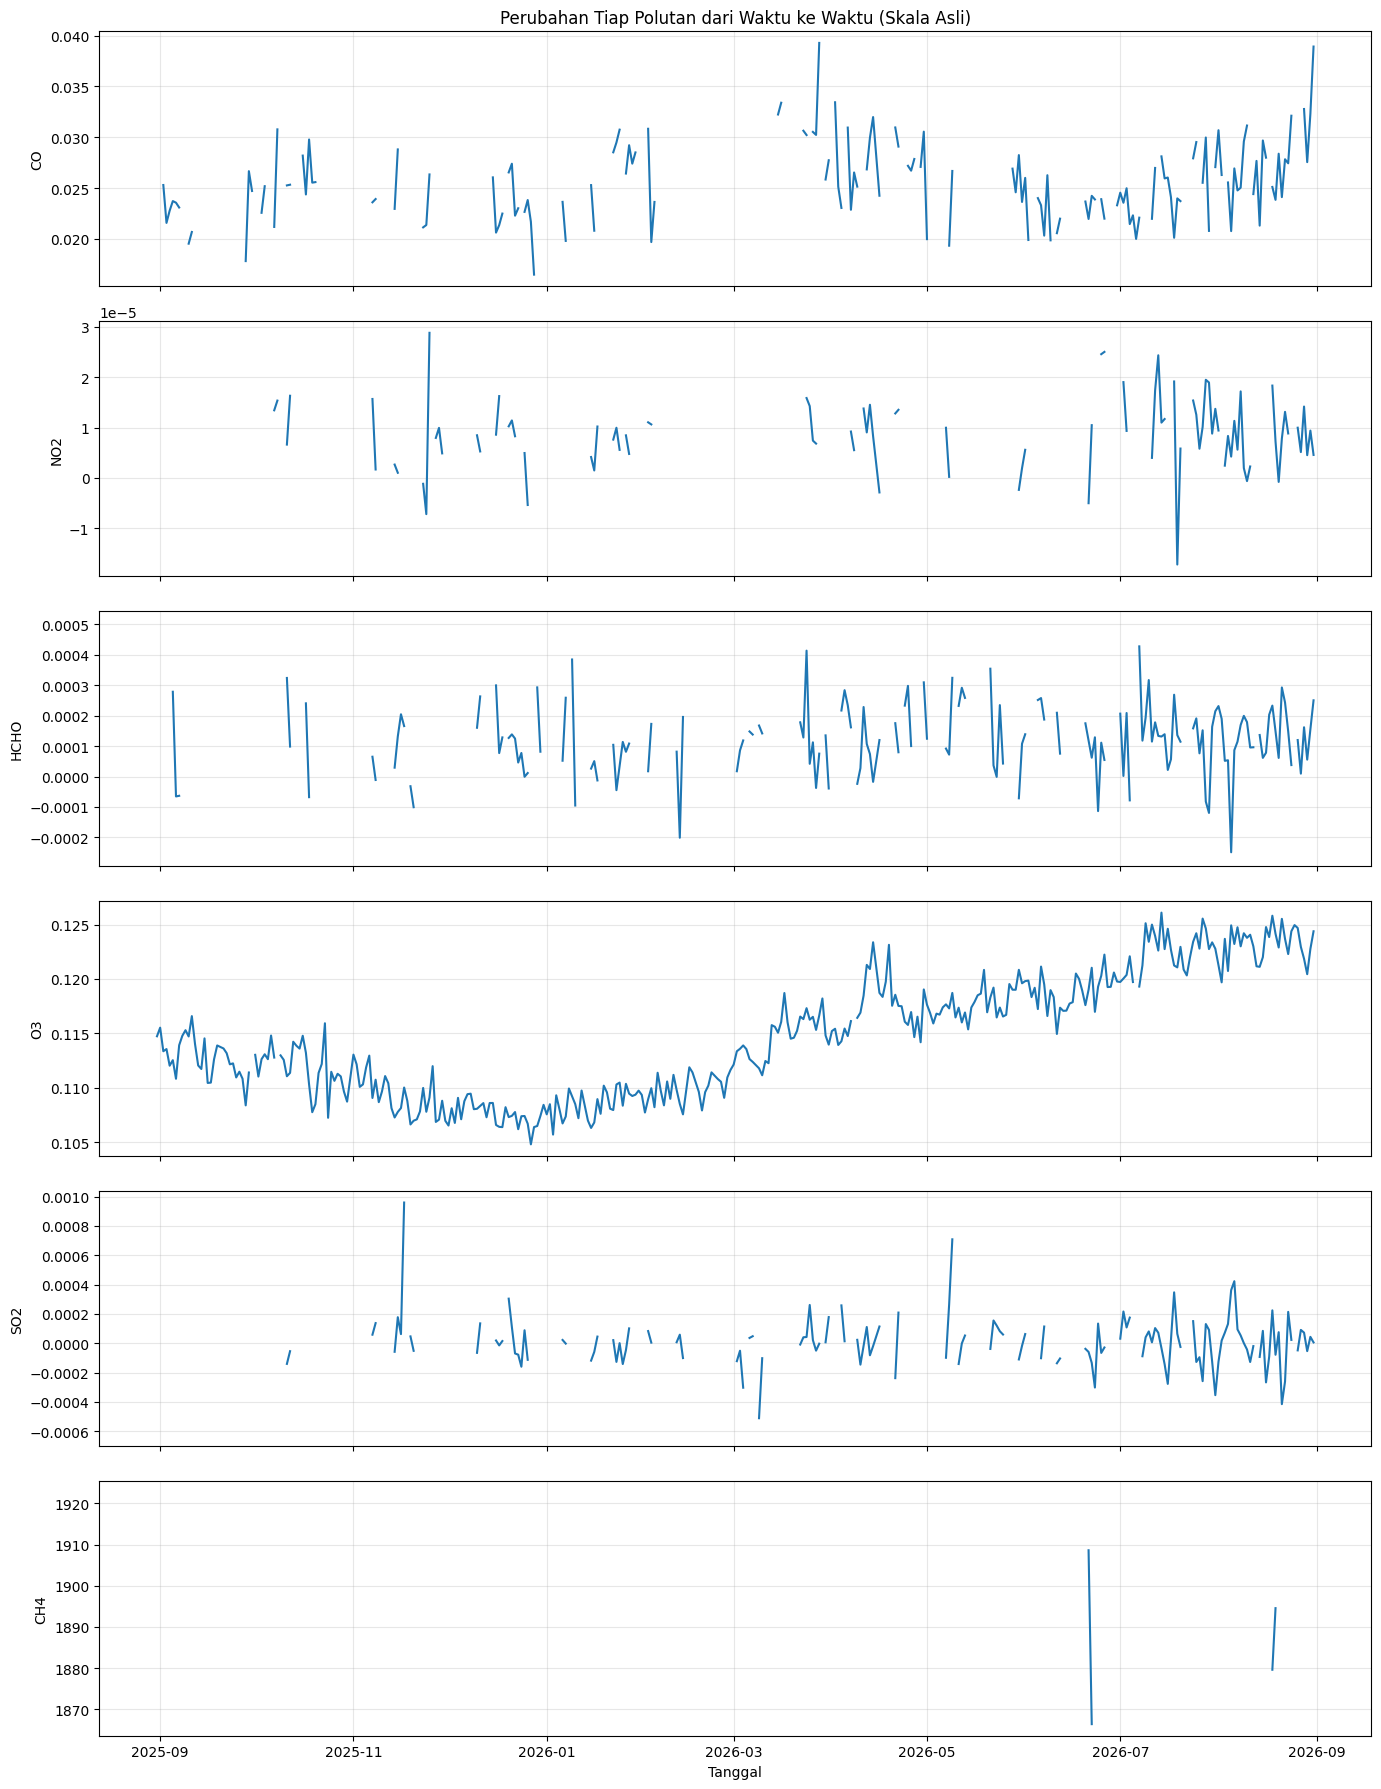

In [15]:
fig, axes = plt.subplots(len(POLLUTANTS), 1, figsize=(14, 3 * len(POLLUTANTS)), sharex=True)

for ax, polutan in zip(axes, POLLUTANTS):
    ax.plot(df["date"], df[polutan], color="tab:blue")
    ax.set_ylabel(polutan)
    ax.grid(alpha=0.3)

axes[0].set_title("Perubahan Tiap Polutan dari Waktu ke Waktu (Skala Asli)")
axes[-1].set_xlabel("Tanggal")

plt.tight_layout()
plt.show()

**penjelasan code:**

* Grafik pertama menampilkan seluruh polutan yang telah dinormalisasi ke rentang 0–1, sehingga dapat ditumpuk dalam satu sumbu meskipun satuannya berbeda-beda.
* Grafik kedua memberikan subplot tersendiri untuk tiap polutan dengan nilai aslinya (tanpa normalisasi), agar CH4 yang datanya sangat terbatas tidak "tenggelam" di dalam grafik gabungan.

### 2.7 Penyimpanan Data ke Database (PostgreSQL — Aiven)

Selain disimpan sebagai file CSV, data polutan juga dipindahkan ke basis data PostgreSQL yang di-hosting di Aiven, sehingga dapat diakses ulang secara terpusat (misalnya dari KNIME atau aplikasi lain) tanpa bergantung pada file lokal.

Kredensial koneksi (host, port, password) disimpan melalui Colab Secrets, bukan ditulis langsung di kode, agar tidak ikut terekspos apabila notebook ini diunggah ke repositori publik.

In [23]:
# membaca ulang CSV pollutant_data_manado.csv, lalu mengunggahnya ke basis data PostgreSQL (Aiven)
import pandas as pd
from sqlalchemy import create_engine
from google.colab import userdata

df_baru = pd.read_csv("pollutant_data_manado.csv")

AIVEN_USER     = userdata.get("AIVEN_USER")
AIVEN_PASSWORD = userdata.get("AIVEN_PASSWORD")
AIVEN_HOST     = userdata.get("AIVEN_HOST")
AIVEN_PORT     = userdata.get("AIVEN_PORT")
AIVEN_DB       = userdata.get("AIVEN_DB")

db_url = f"postgresql+psycopg2://{AIVEN_USER}:{AIVEN_PASSWORD}@{AIVEN_HOST}:{AIVEN_PORT}/{AIVEN_DB}?sslmode=require"
engine = create_engine(db_url)

df_baru.to_sql("Polutan_manado", engine, if_exists="replace", index=False)

print(f"Berhasil! {len(df_baru)} baris terupload ke Aiven.")
print(pd.read_sql('SELECT * FROM "Polutan_manado" LIMIT 5', engine))

Berhasil! 363 baris terupload ke Aiven.
         date        CO   NO2     HCHO        O3       SO2   CH4
0  2025-08-31  0.027904  None      NaN  0.114727       NaN  None
1  2025-09-01       NaN  None      NaN  0.115519       NaN  None
2  2025-09-02  0.025303  None      NaN  0.113351       NaN  None
3  2025-09-03  0.021577  None -0.00003  0.113550 -0.000074  None
4  2025-09-04  0.022777  None      NaN  0.112023       NaN  None


**penjelasan code:**

* `pd.read_csv(...)` membaca berkas `polutan_gresik_timeseries.csv` hasil pengumpulan data Sentinel-5P untuk wilayah Gresik.
* Kredensial (`AIVEN_USER`, `AIVEN_PASSWORD`, `AIVEN_HOST`, `AIVEN_PORT`, `AIVEN_DB`) diambil lewat `userdata.get()` dari Colab Secrets, bukan ditulis langsung, supaya tidak ikut terekspos kalau notebook ini dibagikan atau diunggah ke repository.
* `create_engine()` membentuk koneksi ke PostgreSQL Aiven memakai driver `psycopg2`, dengan `sslmode=require` karena Aiven mewajibkan koneksi terenkripsi.
* `df_gresik.to_sql("Polutan_gresik", engine, if_exists="replace", index=False)` mengirim seluruh isi dataframe ke tabel `Polutan_gresik` di database; opsi `if_exists="replace"` berarti tabel lama (jika ada) akan ditimpa ulang. Nama tabel ini terpisah dari `Polutan_manado`, sehingga kedua wilayah bisa disimpan pada database Aiven yang sama tanpa saling menimpa.
* Dua baris `print()` terakhir untuk verifikasi: menampilkan jumlah baris yang berhasil terupload, dan 5 baris pertama hasil query balik dari tabel tersebut.

### 2.8 Menarik Data dari PostgreSQL (Aiven) ke KNIME

Setelah data polutan tersimpan di basis data Aiven, langkah berikutnya adalah menariknya ke KNIME Analytics Platform untuk eksplorasi lebih lanjut. Alur kerja yang digunakan terdiri dari 4 node yang dihubungkan berurutan: **PostgreSQL Connector → DB Table Selector → DB Reader → Statistics**.

>![](https://cdn.mathpix.com/snip/images/Me4F2IO7mS_uXgzbmVwaMzt4rro_sh5m-rvbEjav6p0.original.fullsize.png)

**1. PostgreSQL Connector**

Node ini membuka koneksi ke server Aiven. Dua port merah (bulat) di bagian atas node adalah input opsional untuk kredensial lewat flow variable (mis. dari node **Credentials Configuration**, jika dipakai); jika tidak dihubungkan, username/password diisi langsung pada tab konfigurasi node ini. Parameter yang diisi:
- *Hostname*: sesuai `AIVEN_HOST` (ex: `pg-xxxxxxxx-postgrependata.f.aivencloud.com`)
- *Port*: sesuai `AIVEN_PORT` (ex: `10874`)
- *Database name*: `defaultdb`
- *Username / Password*: sesuai `AIVEN_USER` / `AIVEN_PASSWORD`
- *SSL Mode*: `require` (Aiven mewajibkan koneksi terenkripsi)

> ![](https://cdn.mathpix.com/snip/images/0SzdWpJ6aBFuGPGUUFl6RZEx5iap6ELZKooCdbHHx64.original.fullsize.png)

**2. DB Table Selector**

Dihubungkan ke output PostgreSQL Connector (port merah kotak di sisi kanan node), lalu memilih tabel `Polutan_manado` yang sudah dibuat sebelumnya melalui `to_sql()`.

> ![](https://cdn.mathpix.com/snip/images/eKyK-cRqD3KTIBKa0StfzXvn97Kw9NtORatPgYjY5jk.original.fullsize.png)

**3. DB Reader**

Mengeksekusi query dari DB Table Selector dan mengubah hasilnya menjadi tabel KNIME biasa (port panah hitam di kanan node), sehingga siap diproses node analisis berikutnya.

> ![](https://cdn.mathpix.com/snip/images/Y7j8e036PkixlvrkcCGQcdMOOpmO3LUhCK27bnYmoO8.original.fullsize.png)

**4. Statistics**

Dihubungkan langsung ke output DB Reader, menghitung ringkasan statistik (mean, median, std. deviation, variance, min, max, quartile, skewness, kurtosis, dll.) untuk tiap kolom polutan. Node ini punya 3 output port: *Statistics Table*, *Nominal Histogram Table*, dan *Occurrences Table*.

> ![](https://cdn.mathpix.com/snip/images/BF5LJPsz5q6ASh96uljXuZkt50q02Ox4ZZtBI09cQbQ.original.fullsize.png)

> ![](https://cdn.mathpix.com/snip/images/J09lQI6OKPA5bKH4m_pRNRnYuCewD3kLnaddSK4J0lU.original.fullsize.png)

> ![](https://cdn.mathpix.com/snip/images/PGsj6hH8VE8Lv2ufeaPnag47USi9NfYXahq62D0sR2k.original.fullsize.png)

Node ini menghasilkan beberapa informasi statistik, seperti:

- **Min** = nilai terkecil
- **Max** = nilai terbesar
- **Mean** = nilai rata-rata
- **Variance** = ukuran penyebaran data terhadap rata-rata
- **Std. Deviation** = standar deviasi
- **Skewness** = ukuran kemencengan distribusi data
- **Kurtosis** = ukuran keruncingan distribusi data
- **Overall Sum** = jumlah seluruh nilai
- **No. missings** = jumlah data yang kosong
- **No. NaNs** = jumlah data yang bernilai NaN
- **No. +oos** = jumlah data positif yang berada di luar batas
- **No. -oos** = jumlah data negatif yang berada di luar batas
- **Median** = nilai tengah data
- **Row Count** = jumlah seluruh baris data
- **Histogram** = visualisasi distribusi data

### 2.9 Contoh Perhitungan Statistics

Sebagai ilustrasi, diambil data kolom **CO** pada lima baris pertama:

| Hari | Tanggal | CO |
|---:|---|---:|
| 1 | 2025-08-31 | 0,027904 |
| 2 | 2025-09-01 | Missing |
| 3 | 2025-09-02 | 0,025303 |
| 4 | 2025-09-03 | 0,021577 |
| 5 | 2025-09-04 | 0,022777 |

Dari kelima baris tersebut, satu di antaranya kosong (missing), sehingga hanya empat nilai yang dipakai dalam perhitungan berikut:

$$
n=4
$$

$$
0,027904;\ 0,025303;\ 0,021577;\ 0,022777
$$

#### 1. Min

Min adalah nilai paling kecil di antara seluruh data yang tersedia.

$$
Min=\min(x_1,x_2,\ldots,x_n)
$$

Dari keempat nilai di atas:

$$
Min=\min(0,027904;\ 0,025303;\ 0,021577;\ 0,022777)=0,021577
$$

Sehingga **Min CO = 0,021577**.

#### 2. Max

Kebalikan dari Min, Max adalah nilai paling besar di antara data yang ada.

$$
Max=\max(x_1,x_2,\ldots,x_n)
$$

$$
Max=\max(0,027904;\ 0,025303;\ 0,021577;\ 0,022777)=0,027904
$$

Sehingga **Max CO = 0,027904**.

#### 3. Mean

Mean menggambarkan nilai tengah keseluruhan data, diperoleh dari total nilai dibagi banyaknya data.

$$
\bar{x}=\frac{\sum_{i=1}^{n}x_i}{n}
$$

$$
\bar{x}=\frac{0,027904+0,025303+0,021577+0,022777}{4}=\frac{0,097561}{4}=0,02439025
$$

Sehingga **Mean CO = 0,024390**.

#### 4. Variance

Variance menunjukkan besarnya penyebaran data terhadap nilai rata-ratanya. Pada contoh ini digunakan rumus *sample variance*:

$$
s^2=\frac{\sum_{i=1}^{n}(x_i-\bar{x})^2}{n-1}
$$

Dengan $\bar{x}=0,02439025$, selisih tiap nilai terhadap mean beserta kuadratnya adalah sebagai berikut:

| $x_i$ | $x_i-\bar{x}$ | $(x_i-\bar{x})^2$ |
|---:|---:|---:|
| 0,027904 | 0,0035138 | 0,0000123464 |
| 0,025303 | 0,0009128 | 0,0000008331 |
| 0,021577 | -0,0028133 | 0,0000079144 |
| 0,022777 | -0,0016133 | 0,0000026026 |

Jumlah seluruh kuadrat selisih tersebut:

$$
\sum(x_i-\bar{x})^2\approx0,0000236965
$$

sehingga:

$$
s^2=\frac{0,0000236965}{4-1}\approx0,0000078988
$$

Diperoleh **Variance CO ≈ 0,0000078988**.

#### 5. Std. Deviation

Standar deviasi merupakan akar dari variance, dan lebih mudah diinterpretasikan karena satuannya sama dengan data aslinya.

$$
s=\sqrt{s^2}=\sqrt{0,0000078988}\approx0,002810
$$

Diperoleh **Std. Deviation CO ≈ 0,002810**.

#### 6. Skewness

Skewness mengukur tingkat kemencengan (asimetri) distribusi data. Perhitungan berikut menggunakan rumus *corrected sample skewness*:

$$
G_1=\frac{n}{(n-1)(n-2)}\sum_{i=1}^{n}\left(\frac{x_i-\bar{x}}{s}\right)^3
$$

Dengan $n=4$, $\bar{x}=0,02439025$, dan $s\approx0,002810$, diperoleh:

$$
G_1\approx0,531
$$

Nilai **Skewness CO ≈ 0,531** ini bertanda positif, menandakan distribusi data sedikit condong ke arah kanan.

#### 7. Kurtosis

Kurtosis menggambarkan tingkat keruncingan distribusi dibandingkan distribusi normal, dihitung dengan rumus *corrected sample excess kurtosis*:

$$
G_2=\frac{n(n+1)}{(n-1)(n-2)(n-3)}\sum_{i=1}^{n}\left(\frac{x_i-\bar{x}}{s}\right)^4-\frac{3(n-1)^2}{(n-2)(n-3)}
$$

Dengan $n=4$, hasil perhitungannya:

$$
G_2\approx-1,611
$$

Nilai **Kurtosis CO ≈ -1,611** yang negatif ini mengindikasikan bahwa distribusi data lebih datar dibandingkan distribusi normal.

#### 8. Overall Sum

Overall Sum adalah total penjumlahan seluruh nilai numerik yang tersedia pada kolom tersebut.

$$
Sum=\sum_{i=1}^{n}x_i
$$

$$
Sum=0,027904+0,025303+0,021577+0,022777=0,097561
$$

Sehingga **Overall Sum CO = 0,097561**.

#### 9. No. Missings

Fitur ini mencatat jumlah baris yang tidak memiliki nilai (kosong) pada kolom tersebut. Dari total 5 baris, hanya 4 yang terisi data CO, sehingga:

$$
No.\ missings=1
$$

#### 10. No. NaNs

Berbeda dari missing value, No. NaNs khusus menghitung nilai yang secara eksplisit bertipe *Not a Number*. Pada contoh ini tidak ditemukan nilai semacam itu:

$$
No.\ NaNs=0
$$

#### 11. No. +oos

Fitur ini menunjukkan banyaknya nilai positif yang berada di luar batas (*out of spec*) yang ditetapkan. Tidak ada data pada contoh ini yang termasuk kategori tersebut:

$$
No.\ +oos=0
$$

#### 12. No. -oos

Sebaliknya, fitur ini menghitung nilai negatif yang berada di luar batas yang ditetapkan. Pada contoh ini juga tidak ditemukan data semacam itu:

$$
No.\ -oos=0
$$

#### 13. Median

Median merupakan nilai yang berada tepat di tengah setelah data diurutkan. Data yang telah diurutkan:

$$
0,021577;\ 0,022777;\ 0,025303;\ 0,027904
$$

Karena jumlah data genap (n = 4), median diambil dari rata-rata dua nilai tengah:

$$
Median=\frac{x_{n/2}+x_{n/2+1}}{2}=\frac{0,022777+0,025303}{2}=\frac{0,04808}{2}=0,02404
$$

Sehingga **Median CO = 0,024040**.

#### 14. Row Count

Row Count menghitung seluruh baris pada tabel, termasuk yang bernilai missing. Pada contoh ini terdapat 5 baris:

$$
Row\ Count=5
$$

Perlu digarisbawahi bahwa Row Count tidak sama dengan jumlah data yang dipakai dalam perhitungan Mean, Variance, dan statistik numerik lainnya, karena nilai yang missing tidak diikutsertakan dalam perhitungan tersebut.

## 3. Data Preparation

### 3.1 Ekstraksi Fitur Time Series dengan TSFEL (Kolom NO2)

Setelah data polutan bersih dari missing value dan outlier, langkah berikutnya adalah mengekstraksi berbagai fitur statistik dan sinyal dari deret waktu NO2 menggunakan pustaka **TSFEL (Time Series Feature Extraction Library)**. Fitur-fitur ini nantinya bisa dipakai sebagai input untuk tahap pemodelan (mis. klasifikasi/klasterisasi kondisi kualitas udara), bukan sekadar ringkasan statistik biasa seperti pada node Statistics sebelumnya.


In [18]:
!pip install tsfel -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.4/63.4 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 53.1 MB/s eta 0:00:00


In [22]:
import pandas as pd
import numpy as np
import inspect
import tsfel.feature_extraction.features as tsfel_features

# ---------- 1. Muat dan bersihkan data ----------
df = pd.read_csv("pollutant_data_manado.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

target_pollutant = 'NO2'

# --- FIX: paksa kolom target jadi numerik, nilai yang gagal dikonversi -> NaN ---
df[target_pollutant] = pd.to_numeric(df[target_pollutant], errors='coerce')

n_missing_before = df[target_pollutant].isna().sum()
print(f"Jumlah nilai non-numerik/kosong yang dikonversi jadi NaN: {n_missing_before}")

Q1 = df[target_pollutant].quantile(0.25)
Q3 = df[target_pollutant].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df.loc[(df[target_pollutant] < lower_bound) | (df[target_pollutant] > upper_bound), target_pollutant] = np.nan

df_clean = df.set_index('date').interpolate(method='time').ffill().bfill()

fs = 1
signal_1d = df_clean[target_pollutant].astype(float).values

# ---------- 2. Daftar PERSIS fitur yang diminta ----------
FEATURE_LIST = """abs_energy auc autocorr average_power calc_centroid calc_max calc_mean
calc_median calc_min calc_std calc_var dfa distance ecdf ecdf_percentile ecdf_percentile_count
ecdf_slope entropy fundamental_frequency higuchi_fractal_dimension hist_mode human_range_energy
hurst_exponent interq_range kurtosis lempel_ziv lpcc max_frequency max_power_spectrum
maximum_fractal_length mean_abs_deviation mean_abs_diff mean_diff median_abs_deviation
median_abs_diff median_diff median_frequency mfcc mse negative_turning neighbourhood_peaks
petrosian_fractal_dimension pk_pk_distance positive_turning power_bandwidth rms skewness slope
spectral_centroid spectral_decrease spectral_distance spectral_entropy spectral_kurtosis
spectral_positive_turning spectral_roll_off spectral_roll_on spectral_skewness spectral_slope
spectral_spread spectral_variation spectrogram_mean_coeff sum_abs_diff wavelet_abs_mean
wavelet_energy wavelet_entropy wavelet_std wavelet_var zero_cross""".split()

print("Jumlah fitur yang diminta:", len(FEATURE_LIST))


def to_scalar(result):
    if isinstance(result, dict) and "values" in result:
        result = result["values"]
    if isinstance(result, (list, tuple, np.ndarray)):
        arr = np.asarray(result, dtype=float)
        return float(np.nanmean(arr))
    return float(result)


def extract_one(fn_name, signal, fs):
    fn = getattr(tsfel_features, fn_name)
    params = inspect.signature(fn).parameters
    if "fs" in params:
        result = fn(signal, fs)
    else:
        result = fn(signal)
    return to_scalar(result)


row = {}
for fn_name in FEATURE_LIST:
    row[fn_name] = extract_one(fn_name, signal_1d, fs)

extracted_features_final = pd.DataFrame([row])

print(f"Berhasil! Jumlah fitur yang dihasilkan untuk {target_pollutant}: {extracted_features_final.shape[1]}")
extracted_features_final.to_csv(f'{target_pollutant}_Tikala_TSFEL.csv', index=False)

Jumlah nilai non-numerik/kosong yang dikonversi jadi NaN: 240
Jumlah fitur yang diminta: 68
Berhasil! Jumlah fitur yang dihasilkan untuk NO2: 68


/usr/local/lib/python3.13/dist-packages/tsfel/feature_extraction/features_utils.py:534: RuntimeWarning: invalid value encountered in divide
  rs = np.divide(r, s)


In [21]:
print(f"Jumlah baris: {extracted_features_final.shape[0]}")
print(f"Jumlah kolom (fitur): {extracted_features_final.shape[1]}")

Jumlah baris: 1
Jumlah kolom (fitur): 68


**penjelasan code:**

* Kolom `NO2` dipaksa jadi tipe numerik lewat `pd.to_numeric(..., errors="coerce")` — nilai yang tidak bisa dikonversi (misalnya teks atau format aneh) otomatis diubah jadi `NaN`, dan jumlahnya dicetak untuk transparansi.
* Outlier dideteksi dengan metode **IQR** (sama seperti Bagian 2.5), lalu nilai yang berada di luar batas `[Q1 − 1.5×IQR, Q3 + 1.5×IQR]` diganti jadi `NaN` — jadi outlier tidak dihapus barisnya, tapi nilainya "dikosongkan" dulu untuk ditangani di langkah berikutnya.
* `df.set_index("date").interpolate(method="time")` mengisi nilai kosong (baik missing asli maupun bekas outlier) dengan interpolasi berbasis waktu, memperhitungkan jarak antar tanggal. Sisa nilai kosong di ujung awal/akhir data (yang tidak bisa diinterpolasi) ditutup dengan `ffill()` (isi dari nilai sebelumnya) dan `bfill()` (isi dari nilai sesudahnya).
* `fs = 1` menetapkan frekuensi sampling sinyal sebagai 1 observasi per hari, karena data memang berupa rata-rata harian.
* `signal_1d` adalah array 1 dimensi berisi seluruh nilai NO2 yang sudah bersih, dalam bentuk yang bisa langsung diproses oleh fungsi-fungsi TSFEL.
* `FEATURE_LIST` berisi 70 nama fungsi ekstraksi fitur bawaan TSFEL yang ingin dihitung — mencakup fitur statistik (`calc_mean`, `calc_std`, `skewness`, `kurtosis`, dll.), fitur domain waktu (`autocorr`, `zero_cross`, `slope`, dll.), fitur domain frekuensi (`spectral_centroid`, `fundamental_frequency`, `mfcc`, dll.), hingga fitur kompleksitas sinyal (`hurst_exponent`, `higuchi_fractal_dimension`, `entropy`, dll.).
* Fungsi `extract_one()` memanggil tiap fungsi TSFEL secara dinamis lewat `getattr()`. Karena tidak semua fungsi TSFEL butuh parameter frekuensi sampling (`fs`), `inspect.signature()` dipakai untuk mengecek dulu apakah parameter itu ada, baru menentukan cara memanggilnya — supaya kode tidak error saat fungsi yang dipanggil ternyata tidak menerima `fs`.
* Fungsi `to_scalar()` menyeragamkan hasil setiap fungsi TSFEL menjadi satu angka tunggal (scalar). Ini perlu karena sebagian fungsi TSFEL mengembalikan satu angka, sementara sebagian lain mengembalikan list/array (misalnya untuk beberapa koefisien MFCC atau wavelet) — kalau berbentuk list/array, diambil rata-ratanya (`np.nanmean`) sebagai representasi tunggal.
* Loop `for fn_name in FEATURE_LIST` menjalankan `extract_one()` untuk tiap fitur pada `FEATURE_LIST`, hasilnya dikumpulkan dalam dictionary `row` dengan nama fitur sebagai key.
* `pd.DataFrame([row])` mengubah dictionary tersebut menjadi tabel satu baris, di mana setiap kolom adalah satu fitur hasil ekstraksi TSFEL untuk kolom NO2.
* Hasil akhirnya disimpan sebagai berkas `NO2_Tikala_TSFEL.csv`, siap dipakai pada tahap analisis atau pemodelan berikutnya.

#### 3.1.1 Penjelasan Fitur Ekstraksi TSFEL

TSFEL mengelompokkan fitur ke dalam **4 domain resmi**: Statistical, Temporal, Spectral, dan Fractal. Total fitur yang diekstraksi pada kode ini: **68 fitur** (21 + 15 + 26 + 6).

##### a. Domain Statistical (21 fitur)
Mengukur karakteristik distribusi nilai sinyal, tanpa memperhatikan urutan waktu.

| Fitur | Penjelasan |
|---|---|
| `abs_energy` | Menghitung total energi absolut sinyal (jumlah kuadrat seluruh nilai) |
| `average_power` | Menghitung daya rata-rata sinyal per satuan waktu |
| `calc_max` | Mengambil nilai maksimum sinyal |
| `calc_mean` | Menghitung nilai rata-rata sinyal |
| `calc_median` | Mengambil nilai tengah sinyal setelah diurutkan |
| `calc_min` | Mengambil nilai minimum sinyal |
| `calc_std` | Menghitung standar deviasi (sebaran) sinyal |
| `calc_var` | Menghitung variansi sinyal |
| `ecdf` | Menghitung nilai fungsi distribusi kumulatif empiris (ECDF) sepanjang sinyal |
| `ecdf_percentile` | Mengambil nilai sinyal pada persentil tertentu dari ECDF |
| `ecdf_percentile_count` | Menghitung jumlah sampel kumulatif di bawah persentil tertentu |
| `ecdf_slope` | Menghitung kemiringan (slope) ECDF antara dua persentil |
| `entropy` | Mengukur tingkat ketidakteraturan/keacakan sinyal (Shannon entropy) |
| `hist_mode` | Mengambil modus (nilai paling sering muncul) dari histogram sinyal |
| `interq_range` | Menghitung rentang interkuartil (Q3−Q1), ukuran sebaran data tengah |
| `kurtosis` | Mengukur keruncingan distribusi sinyal dibanding distribusi normal |
| `mean_abs_deviation` | Menghitung rata-rata deviasi absolut dari mean |
| `median_abs_deviation` | Menghitung median deviasi absolut dari median |
| `pk_pk_distance` | Menghitung jarak antara nilai maksimum dan minimum (peak-to-peak) |
| `rms` | Menghitung root mean square, ukuran magnitudo keseluruhan sinyal |
| `skewness` | Mengukur kemencengan/asimetri distribusi sinyal |

##### b. Domain Temporal (15 fitur)
Mengukur pola perubahan sinyal terhadap waktu (urutan data diperhatikan).

| Fitur | Penjelasan |
|---|---|
| `auc` | Menghitung luas area di bawah kurva sinyal (area under curve) |
| `autocorr` | Mencari lag pertama saat autokorelasi turun di bawah 1/e — mengukur seberapa mirip sinyal dengan versi tergesernya |
| `calc_centroid` | Menghitung titik pusat (centroid) sinyal di sepanjang sumbu waktu |
| `distance` | Menghitung total jarak tempuh sinyal dari titik ke titik |
| `lempel_ziv` | Mengukur kompleksitas Lempel-Ziv — seberapa "acak"/tidak berulang pola sinyal |
| `mean_abs_diff` | Menghitung rata-rata selisih absolut antar titik berurutan |
| `mean_diff` | Menghitung rata-rata selisih (bertanda) antar titik berurutan |
| `median_abs_diff` | Menghitung median selisih absolut antar titik berurutan |
| `median_diff` | Menghitung median selisih antar titik berurutan |
| `negative_turning` | Menghitung jumlah titik balik negatif (dari naik ke turun) |
| `neighbourhood_peaks` | Menghitung jumlah puncak lokal berdasarkan wilayah tetangga tertentu |
| `positive_turning` | Menghitung jumlah titik balik positif (dari turun ke naik) |
| `slope` | Menghitung kemiringan garis tren linear sinyal terhadap waktu |
| `sum_abs_diff` | Menghitung total selisih absolut antar titik berurutan |
| `zero_cross` | Menghitung berapa kali sinyal melewati nilai nol (berganti tanda) |

##### c. Domain Spectral (26 fitur)
Mengubah sinyal ke ranah frekuensi (lewat FFT/wavelet) lalu mengukur karakteristiknya di sana.

| Fitur | Penjelasan |
|---|---|
| `fundamental_frequency` | Mencari frekuensi dominan/utama pada sinyal |
| `human_range_energy` | Menghitung rasio energi sinyal pada rentang 0,6–2,5 Hz terhadap total energi |
| `lpcc` | Menghitung koefisien cepstral prediksi linear (Linear Prediction Cepstral Coefficients) |
| `max_frequency` | Mencari frekuensi di mana 95% energi sinyal sudah terkumpul secara kumulatif |
| `max_power_spectrum` | Mengambil nilai maksimum kerapatan daya spektral sinyal |
| `median_frequency` | Mencari frekuensi di mana 50% energi sinyal sudah terkumpul |
| `mfcc` | Menghitung koefisien cepstral Mel-frequency — representasi spektrum dalam skala mel |
| `power_bandwidth` | Menghitung lebar pita frekuensi yang mengandung 95% daya sinyal |
| `spectral_centroid` | Menghitung titik pusat massa (barycenter) spektrum frekuensi |
| `spectral_decrease` | Mengukur seberapa besar penurunan amplitudo spektrum seiring naiknya frekuensi |
| `spectral_distance` | Menghitung jarak spektrum kumulatif sinyal terhadap garis regresi linearnya |
| `spectral_entropy` | Mengukur entropi (ketidakteraturan) dari distribusi energi spektral |
| `spectral_kurtosis` | Mengukur keruncingan distribusi spektrum frekuensi |
| `spectral_positive_turning` | Menghitung jumlah titik balik positif pada magnitude hasil FFT |
| `spectral_roll_off` | Mencari frekuensi di mana 95% energi spektrum berada di bawahnya |
| `spectral_roll_on` | Mencari frekuensi di mana 5% energi spektrum berada di bawahnya |
| `spectral_skewness` | Mengukur kemencengan/asimetri distribusi spektrum frekuensi |
| `spectral_slope` | Menghitung kemiringan garis regresi linear dari amplitudo spektrum |
| `spectral_spread` | Mengukur sebaran spektrum di sekitar titik centroid-nya |
| `spectral_variation` | Mengukur seberapa besar variasi spektrum antar waktu (korelasi silang dua spektrum berurutan) |
| `spectrogram_mean_coeff` | Menghitung rata-rata kerapatan daya spektral tiap bin frekuensi sepanjang durasi sinyal |
| `wavelet_abs_mean` | Menghitung rata-rata absolut koefisien wavelet tiap skala |
| `wavelet_energy` | Menghitung energi koefisien wavelet tiap skala |
| `wavelet_entropy` | Mengukur entropi dari distribusi energi wavelet antarskala |
| `wavelet_std` | Menghitung standar deviasi koefisien wavelet tiap skala |
| `wavelet_var` | Menghitung variansi koefisien wavelet tiap skala |

#### d. Domain Fractal / Kompleksitas (6 fitur)
Mengukur kompleksitas dan sifat "memori jangka panjang" sinyal — domain ini sebelumnya belum tercantum di dokumen awal.

| Fitur | Penjelasan |
|---|---|
| `dfa` | Menghitung Detrended Fluctuation Analysis — mengukur ada tidaknya korelasi/pola jangka panjang pada sinyal, meski sinyalnya tidak stasioner |
| `higuchi_fractal_dimension` | Menghitung dimensi fraktal sinyal dengan metode Higuchi — mengukur seberapa "kasar/rumit" bentuk sinyal |
| `hurst_exponent` | Menghitung eksponen Hurst lewat analisis Rescaled Range (R/S) — mengindikasikan apakah sinyal cenderung persisten, acak, atau anti-persisten dari waktu ke waktu |
| `maximum_fractal_length` | Menghitung Maximum Fractal Length (MFL) — panjang rata-rata sinyal pada skala terkecil, diukur dari plot logaritmik penentuan dimensi fraktal |
| `mse` | Menghitung Multiscale Entropy — mengukur tingkat ketidakteraturan sinyal pada berbagai skala waktu sekaligus |
| `petrosian_fractal_dimension` | Menghitung dimensi fraktal Petrosian — versi lebih ringan/cepat dihitung dibanding metode Higuchi, tetap mengukur kompleksitas bentuk sinyal |